In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
metrics_dir=os.path.join(os.getcwd(),"metrics")
# --- LOAD THE .pkl FILE GENERATED PREVIOUSLY ---
adapt=0
test_ds_b4=False
if test_ds_b4:
    identifier=f"testing_dsb4_adaptable{adapt}" if adapt > 0 else "testing_dsb4"
else:
    identifier=f"30000_1000_100_adaptable{adapt}" if adapt > 0 else "30000_1000_100"
    # identifier="1000_200_median"


In [3]:
filename= f"channel_metrics_by_network_{identifier}.csv"
results_df= pd.read_csv(os.path.join(metrics_dir, filename))
print(f"Results loaded from {os.path.join(metrics_dir, filename)}")
print(results_df.head())

Results loaded from c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch\eval\live_results\metrics\channel_metrics_by_network_30000_1000_100.csv
                   Network                     Dataset  Channel   TP   FP  FN  \
0  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        0  215  786   9   
1  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        1  203  480  21   
2  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        2  183  259  41   
3  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        3  146  112  78   
4  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        4  142  178  82   

   Precision    Recall        F1  
0   0.214785  0.959821  0.351020  
1   0.297218  0.906250  0.447630  
2   0.414027  0.816964  0.549550  
3   0.565891  0.651786  0.605809  
4   0.443750  0.633929  0.522059  


In [4]:
from matplotlib.patches import Patch


def plot_whiskers_by_dataset(df, metrics=["Precision", "Recall", "F1"], colors=None,back_colors=None,add_overall=True):
    if colors is None:
        colors = {
            "Precision": "royalblue",
            "Recall": "seagreen",
            "F1": "darkorange"
        }
    labels=["Amigo","Dlx","Som","Thy","Overall"]
    df = df.copy()  # avoid modifying original DataFrame

    # Compute and add "Overall" if requested
    if add_overall:
        overall_rows = df[metrics].copy()
        overall_rows["Dataset"] = "Overall"
        df = pd.concat([df, overall_rows], ignore_index=True)

    # Get dataset list and ensure "Overall" is last
    datasets = sorted(df['Dataset'].unique())
    if "Overall" in datasets:
        datasets = [d for d in datasets if d != "Overall"] + ["Overall"]

    width = 1  # Width of each box
    fig, ax = plt.subplots(figsize=(12, 6))

    positions = []
    data = []
    plot_colors = []
    xticks = []
    xtick_labels = []

    for i, dataset in enumerate(datasets):
        base_pos = i * (len(metrics) + 1)  # spacing between groups
        for j, metric in enumerate(metrics):
            vals = df[df['Dataset'] == dataset][metric].dropna().values
            pos = base_pos + j * width
            data.append(vals)
            positions.append(pos)
            plot_colors.append(colors.get(metric, "gray"))

        # X-axis ticks centered on group
        xticks.append(base_pos + (len(metrics) - 1) * width / 2)
        xtick_labels.append(labels[i])

        # Background shading
        if back_colors and dataset in back_colors:
            ax.axvspan(base_pos - 0.7, base_pos + len(metrics) * width - 0.3, color=back_colors[dataset], alpha=0.1)
        else:
            ax.axvspan(base_pos - 0.7, base_pos + len(metrics) * width - 0.3, color="lightgray", alpha=0.1)

    # Draw boxplots
    for d, p, c in zip(data, positions, plot_colors):
        bplot = ax.boxplot(d, positions=[p], widths=width, patch_artist=True,
                           showfliers=False, medianprops=dict(color='black'))
        for patch in bplot['boxes']:
            patch.set_facecolor(c)

    # Aesthetics
    ax.tick_params(axis='y', which='major', labelsize=12)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Precision, Recall, and F1 Score per Dataset", fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(-1, len(datasets) * (len(metrics) + 1) - 1)
    ax.set_ylim(0, 1)  # Assuming scores are between 0 and 1

    # Clean up
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    # Legend
    legend_handles = [Patch(facecolor=colors[m], label=m) for m in metrics]
    ax.legend(handles=legend_handles, fontsize=12, loc='upper left', bbox_to_anchor=(1.01, 0.5))

    plt.tight_layout()
    plt.show()
    return fig, ax

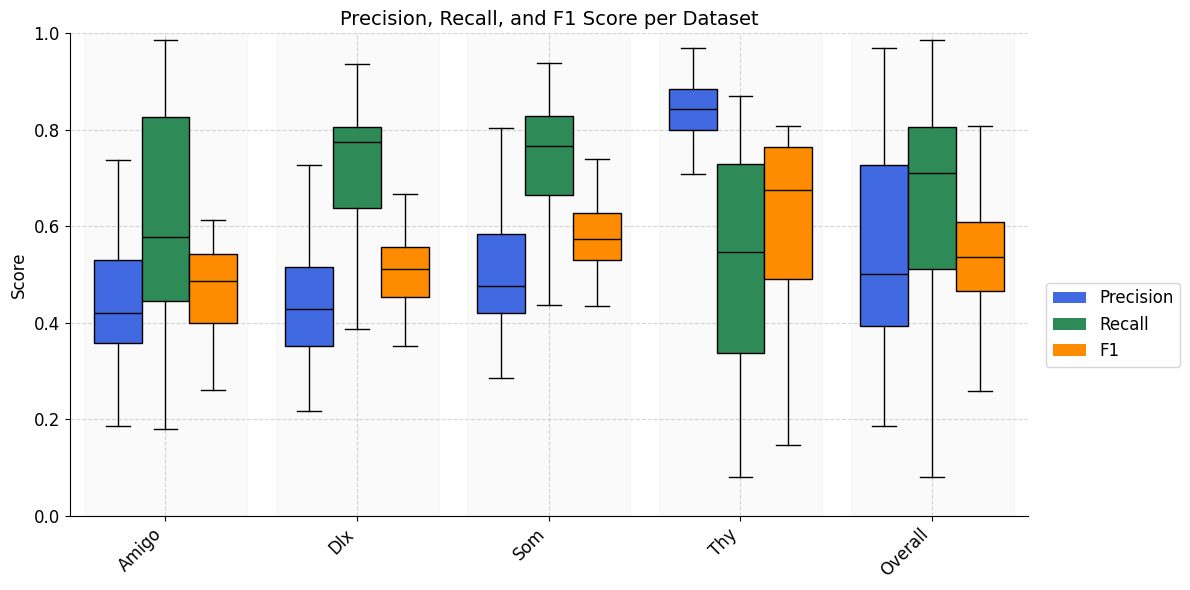

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Precision, Recall, and F1 Score per Dataset'}, ylabel='Score'>)

In [5]:
plot_whiskers_by_dataset(results_df)
# Channel-wise, by dataset


In [6]:
import pandas as pd

def summarize_metrics_by_dataset_and_network(df, metrics=["Precision", "Recall", "F1"]):
    summary_rows = []

    datasets = sorted(df['Dataset'].unique())

    # Summarize per dataset
    for dataset in datasets:
        subset = df[df['Dataset'] == dataset][metrics]
        row = {"Dataset": dataset}
        for metric in metrics:
            vals = subset[metric].dropna()
            row[f"{metric} Mean ± Std"] = f"{vals.mean():.3f} ± {vals.std():.3f}"
            row[f"{metric} Median"] = f"{vals.median():.3f}"
            row[f"{metric} Peak"] = f"{vals.max():.3f}"
        summary_rows.append(row)

    # Compute mean metrics per network across datasets
    # Assuming df has a 'Network' column
    network_means = df.groupby('Network')[metrics].mean()

    overall_row = {"Dataset": "Overall"}

    for metric in metrics:
        all_vals = df[metric].dropna()
        mean = all_vals.mean()
        std = all_vals.std()
        median = all_vals.median()

        # Find network with best average metric across datasets
        best_network = network_means[metric].idxmax()
        best_network_avg = network_means.loc[best_network, metric]

        overall_row[f"{metric} Mean ± Std"] = f"{mean:.3f} ± {std:.3f}"
        overall_row[f"{metric} Median"] = f"{median:.3f}"
        overall_row[f"{metric} Peak"] = f"{best_network_avg:.3f}"

    summary_rows.append(overall_row)

    summary_df = pd.DataFrame(summary_rows)
    return summary_df


In [7]:
summarize_metrics_by_dataset_and_network(results_df, metrics=["Precision", "Recall", "F1"])

,Dataset,Precision Mean ± Std,Precision Median,Precision Peak,Recall Mean ± Std,Recall Median,Recall Peak,F1 Mean ± Std,F1 Median,F1 Peak
0,Amigo2_2019-07-11_11-57-07,0.436 ± 0.123,0.421,0.737,0.616 ± 0.220,0.578,0.987,0.472 ± 0.092,0.486,0.613
1,Dlx1_2021-02-12_12-46-54,0.429 ± 0.108,0.428,0.727,0.708 ± 0.155,0.774,0.935,0.509 ± 0.070,0.510,0.667
2,Som2_2019-07-24_12-01-49,0.504 ± 0.123,0.476,0.839,0.740 ± 0.121,0.766,0.938,0.580 ± 0.071,0.573,0.739
3,Thy7_2020-11-11_16-05-00,0.838 ± 0.065,0.843,0.970,0.520 ± 0.229,0.547,0.871,0.605 ± 0.185,0.676,0.808
4,Overall,0.552 ± 0.199,0.500,0.695,0.646 ± 0.205,0.710,0.759,0.542 ± 0.126,0.535,0.570


In [8]:
def get_network_means_per_dataset(df, metrics=["Precision", "Recall", "F1"]):
    # Assuming df has columns: Dataset, Network, Channel (optional), metrics...
    # Group by Dataset and Network, average over channels
    grouped = df.groupby(['Dataset', 'Network'])[metrics].mean().reset_index()
    return grouped
def plot_whiskers_by_dataset_network_means(df, metrics=["Precision", "Recall", "F1"], colors=None, back_colors=None, add_overall=True):
    if colors is None:
        colors = {
            "Precision": "royalblue",
            "Recall": "seagreen",
            "F1": "darkorange"
        }
    labels=["Amigo","Dlx","Som","Thy"]

    if add_overall:
        labels.append("Overall")

    # Prepare data: group by Dataset and Network, get network means per dataset
    grouped = get_network_means_per_dataset(df, metrics=metrics)

    # Add "Overall" row if requested: mean across all datasets for each network
    if add_overall:
        overall_means = grouped.groupby('Network')[metrics].mean().reset_index()
        overall_means['Dataset'] = 'Overall'
        grouped = pd.concat([grouped, overall_means], ignore_index=True)

    datasets = sorted(grouped['Dataset'].unique())
    if "Overall" in datasets:
        datasets = [d for d in datasets if d != "Overall"] + ["Overall"]

    width = 1  # width of each box
    fig, ax = plt.subplots(figsize=(12, 6))

    positions = []
    data = []
    plot_colors = []
    xticks = []
    xtick_labels = []

    for i, dataset in enumerate(datasets):
        base_pos = i * (len(metrics) + 1)  # spacing between groups
        for j, metric in enumerate(metrics):
            vals = grouped[grouped['Dataset'] == dataset][metric].dropna().values
            pos = base_pos + j * width
            data.append(vals)
            positions.append(pos)
            plot_colors.append(colors.get(metric, "gray"))

        # X-axis ticks centered on group
        xticks.append(base_pos + (len(metrics) - 1) * width / 2)
        xtick_labels.append(labels[i])

        # Background shading
        if back_colors and dataset in back_colors:
            ax.axvspan(base_pos - 0.7, base_pos + len(metrics) * width - 0.3, color=back_colors[dataset], alpha=0.1)
        else:
            ax.axvspan(base_pos - 0.7, base_pos + len(metrics) * width - 0.3, color="lightgray", alpha=0.1)

    # Draw boxplots
    for d, p, c in zip(data, positions, plot_colors):
        bplot = ax.boxplot(d, positions=[p], widths=width, patch_artist=True,
                           showfliers=False, medianprops=dict(color='black'))
        for patch in bplot['boxes']:
            patch.set_facecolor(c)

    # Aesthetics
    ax.tick_params(axis='y', which='major', labelsize=12)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Precision, Recall, and F1 Score per Dataset (Network Means)", fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(-1, len(datasets) * (len(metrics) + 1) - 1)
    ax.set_ylim(0, 1)  # Assuming scores are between 0 and 1
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    legend_handles = [Patch(facecolor=colors[m], label=m) for m in metrics]
    ax.legend(handles=legend_handles, fontsize=12, loc='upper left', bbox_to_anchor=(1.01, 0.5))

    plt.tight_layout()
    plt.show()
    return fig, ax

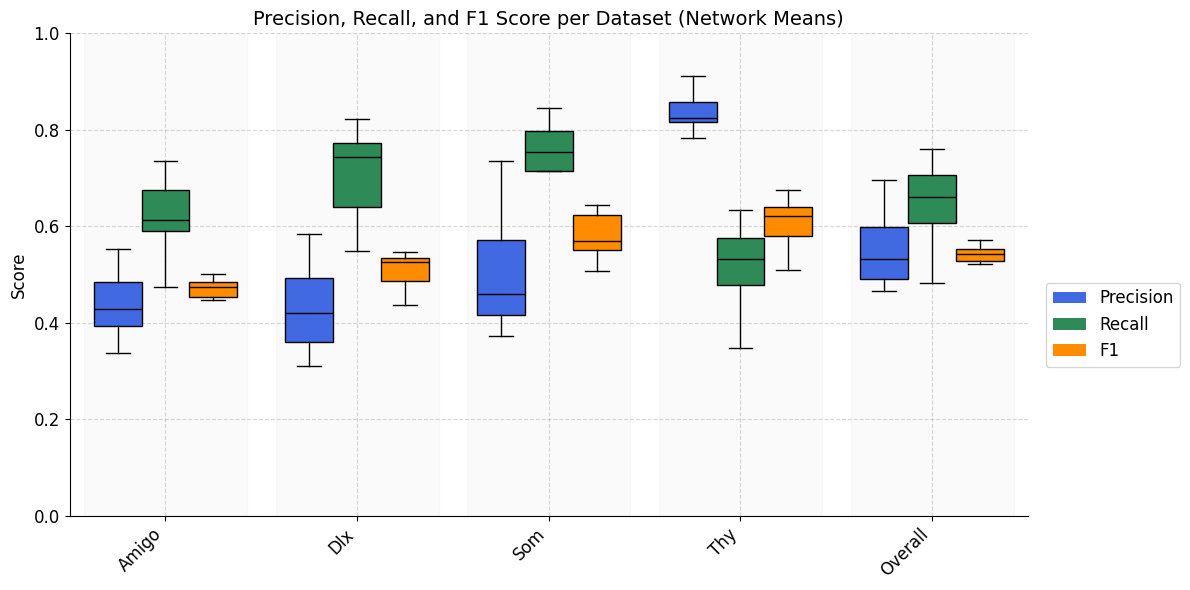

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Precision, Recall, and F1 Score per Dataset (Network Means)'}, ylabel='Score'>)

In [9]:
plot_whiskers_by_dataset_network_means(results_df, metrics=["Precision", "Recall", "F1"])

In [10]:
def summarize_metrics_by_dataset_and_network_averaged(df, metrics=["Precision", "Recall", "F1"]):
    summary_rows = []

    # Step 1: Average metrics per (Dataset, Network) → averaging over channels
    dataset_network_means = df.groupby(['Dataset', 'Network'])[metrics].mean().reset_index()

    datasets = sorted(dataset_network_means['Dataset'].unique())

    # Step 2: Summarize per dataset, using network means (averaged over channels)
    for dataset in datasets:
        subset = dataset_network_means[dataset_network_means['Dataset'] == dataset]
        row = {"Dataset": dataset}
        for metric in metrics:
            vals = subset[metric].dropna()
            row[f"{metric} Mean ± Std"] = f"{vals.mean():.3f} ± {vals.std():.3f}"
            row[f"{metric} Median"] = f"{vals.median():.3f}"
            row[f"{metric} Peak"] = f"{vals.max():.3f}"
        summary_rows.append(row)

    # Step 3: Average those means across datasets to get per-network overall means
    network_overall_means = dataset_network_means.groupby('Network')[metrics].mean()

    overall_row = {"Dataset": "Overall"}

    # Step 4: Overall mean, std, median from raw values (all channels, all datasets, all networks)
    for metric in metrics:
        all_vals = df[metric].dropna()
        mean = all_vals.mean()
        std = all_vals.std()
        median = all_vals.median()

        # Step 5: Find best network by highest mean across datasets
        best_network = network_overall_means[metric].idxmax()
        best_network_avg = network_overall_means.loc[best_network, metric]

        overall_row[f"{metric} Mean ± Std"] = f"{mean:.3f} ± {std:.3f}"
        overall_row[f"{metric} Median"] = f"{median:.3f}"
        overall_row[f"{metric} Peak"] = f"{best_network_avg:.3f} ({best_network})"

    summary_rows.append(overall_row)

    summary_df = pd.DataFrame(summary_rows)
    return summary_df

In [11]:
summarize_metrics_by_dataset_and_network_averaged(results_df, metrics=["Precision", "Recall", "F1"])

,Dataset,Precision Mean ± Std,Precision Median,Precision Peak,Recall Mean ± Std,Recall Median,Recall Peak,F1 Mean ± Std,F1 Median,F1 Peak
0,Amigo2_2019-07-11_11-57-07,0.436 ± 0.063,0.429,0.553,0.616 ± 0.088,0.613,0.735,0.472 ± 0.019,0.475,0.501
1,Dlx1_2021-02-12_12-46-54,0.429 ± 0.084,0.420,0.584,0.708 ± 0.096,0.744,0.823,0.509 ± 0.034,0.526,0.546
2,Som2_2019-07-24_12-01-49,0.504 ± 0.116,0.460,0.736,0.740 ± 0.083,0.754,0.846,0.580 ± 0.049,0.569,0.643
3,Thy7_2020-11-11_16-05-00,0.838 ± 0.042,0.825,0.911,0.520 ± 0.087,0.531,0.633,0.605 ± 0.062,0.622,0.675
4,Overall,0.552 ± 0.199,0.500,0.695 (dsb4updn_median_200_12b),0.646 ± 0.205,0.710,0.759 (adapt20_3b),0.542 ± 0.126,0.535,0.570 (updnb4ds_100_7)


In [23]:
def plot_precision_recall_by_dataset(df):

    # Define consistent colors and labels per dataset
    list_datasets=sorted(df["Dataset"].unique())
    dataset_labels = {
        list_datasets[0]: "Amigo",
        list_datasets[1]: "Dlx",
        list_datasets[2]: "Som",
        list_datasets[3]: "Thy"
    }
    dataset_colors = {
        "Amigo": "#E69F00",  # orange
        "Dlx": "#56B4E9",    # sky blue
        "Som": "#009E73",    # teal
        "Thy": "#F0E442",    # yellow
    }
   

    plt.figure(figsize=(8, 6))

    # Plot each dataset group
    for dataset in sorted(df["Dataset"].unique()):
        group = df[df["Dataset"] == dataset]
        label=dataset_labels.get(dataset, dataset)
        color=dataset_colors.get(label, "gray")
        plt.scatter(
            group["Recall"], group["Precision"],
            label=label,color=color,
            alpha=0.8,
            s=60,
            edgecolors='black'
        )

    # Aesthetics
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("Recall", fontsize=12)
    plt.ylabel("Precision", fontsize=12)
    plt.title("Precision vs. Recall by Dataset", fontsize=14)
    plt.legend(title="Dataset", title_fontsize=13, fontsize=12, loc='center left',bbox_to_anchor=(1.01, 0.5))
    plt.grid(True, linestyle='--', alpha=0.6)

    # Optional: remove top/right spines
    for spine in ['top', 'right']:
        plt.gca().spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()


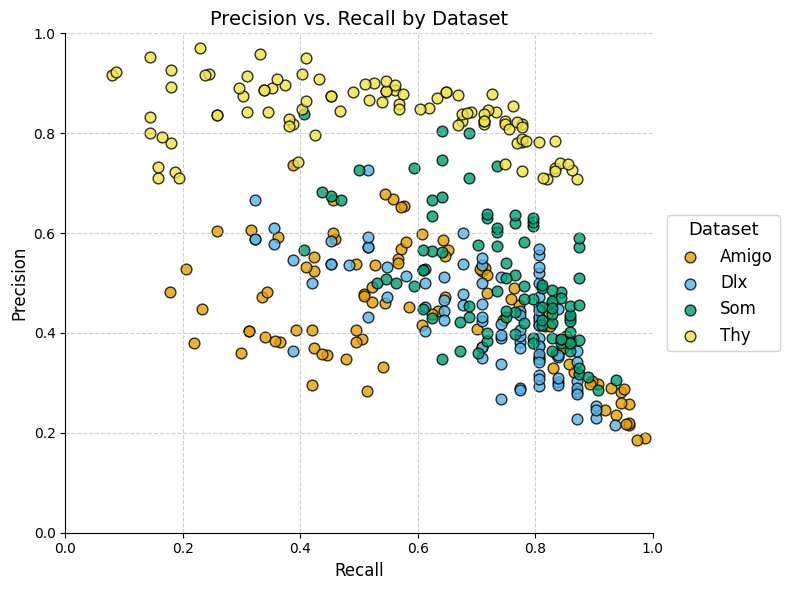

In [24]:
plot_precision_recall_by_dataset(results_df)